# 01 — Data Preparation

## Goal
Parse tBLASTn results for MROH6 in the zebra finch genome, merge fragmented hits
into biologically meaningful loci, filter for quality, classify by chromosomal
origin, and produce a multiple sequence alignment for downstream evolutionary
analysis.

## Scientific context

**MROH6** (Maestro Heat-Like Repeat Family Member 6) encodes a protein
containing HEAT-like repeats — alpha-helical solenoid structures that mediate
protein-protein interactions (Andrade & Bork, 1995, *Nature Genetics*
11:115–116). In most vertebrate genomes, MROH6 exists as a **single-copy gene**
adjacent to the lanosterol synthase gene (LSS) on a single chromosome.

In the zebra finch (*Taeniopygia guttata*; Warren et al., 2010, *Nature*
464:757–762), a tBLASTn search (By Dr. Monacco) of the MROH6 protein against the
genome assembly (bTaeGut1.4.pri; Rhie et al., 2021, *Nature* 592:737–746)
returned **3,039 hits** — an extraordinary amplification from a single-copy
gene. This raises a fundamental question: **what duplication mechanism generated
thousands of MROH6 copies?**

### Two competing hypotheses

| Feature | DNA-mediated duplication | RNA-mediated duplication (retrotransposition) |
|---|---|---|
| **Mechanism** | Unequal crossing-over or segmental duplication during DNA replication | mRNA → cDNA via reverse transcriptase → genomic insertion |
| **Error rate** | ~10⁻⁹–10⁻¹⁰ per base/replication (Kunkel, 2004, *J Biol Chem* 279:16895) | ~10⁻⁴–10⁻⁵ per base/cycle (Preston, 1996, *Science* 275:228) |
| **Expected distribution** | Tandem clusters near parental locus | Dispersed across chromosomes (random insertion) |
| **Expected divergence** | Low (~0.01–0.05 subs/site; Lynch & Conery, 2000, *Science* 290:1151) | Elevated (RT errors + neutral drift) |
| **Ts/Tv ratio** | ~0.5 (random expectation) | >1.0 (RT transition bias; Wakeley, 1996, *J Mol Evol* 42:681) |

### Key observations from karyotype figures
- MROH6 copies are **massively amplified on microchromosomes** (chr 16, 25,
  29–37)
- The **ancestral locus** is on **chromosome 7** near LSS (~28.8 Mb)
- Copies are **dispersed** across entire chromosome lengths (not tandem
  clusters) → retrotransposition signature
- The expansion is **species-specific** to zebra finch (house sparrow has far
  fewer copies)

### Why tBLASTn?
tBLASTn translates a nucleotide database in all six reading frames and searches
it with a protein query (Gertz et al., 2006, *BMC Bioinformatics* 7:326). This
is the correct tool because: (1) it finds copies regardless of reading frame
shifts or frameshifts that would prevent detection with BLASTn, (2)
protein-level homology is more sensitive than nucleotide-level for detecting
divergent copies, and (3) it naturally handles the ~3× redundancy of the genetic
code.

## Strategy
Filter fragments ≥ 300 bp to retain loci with sufficient alignment signal. Very
short fragments (<300 bp) produce unreliable divergence estimates and inflate
NaN rates in pairwise comparisons (Nei & Kumar, 2000, *Molecular Evolution and
Phylogenetics*, Oxford University Press, recommend ≥200–300 aligned positions
for reliable distance estimation).

**Input:** `data/raw/MROH6_tBLASTn_Zebra_finch.txt` (3,039 hits)
**Outputs:** `data/processed/mroh6_copies_filtered.fasta`,
`data/processed/mroh6_aligned.fasta`, `data/processed/mroh6_loci_table.csv`

In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pathlib import Path
import subprocess

from utils import parse_blast_fasta, merge_overlapping_hits, loci_to_fasta

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
RESULTS = Path('../results')

sns.set_context('notebook')
sns.set_style('whitegrid')

## 1a. Parse BLAST results

**Why this step:** The raw tBLASTn output is a FASTA file where each hit is a
separate sequence record with genomic coordinates embedded in the header (e.g.,
`NC_133032.1:28834524-28834700` for forward strand,
`NC_133032.1:c27748619-27748443` for complement). We need to extract the
chromosome, start/end positions, strand, and nucleotide sequence into a
structured DataFrame for downstream filtering and merging.

**What `parse_blast_fasta()` does:** For each FASTA record, it parses the
NCBI-format coordinate string, maps the accession number to a chromosome name,
determines strand orientation from the "c" prefix (complement), and stores the
nucleotide sequence. This converts unstructured BLAST output into a queryable
table with columns: `accession`, `chrom`, `start`, `end`, `strand`, `seq_len`,
`sequence`.

**Why we examine the chromosome distribution first:** The chromosomal
distribution of hits is the first qualitative test of the retrotransposition
hypothesis. If MROH6 copies arose via DNA-mediated tandem duplication, we would
expect most hits to cluster on chromosome 7 near the ancestral locus. If they
arose via retrotransposition, we expect dispersal across many chromosomes —
especially microchromosomes, which in birds have higher gene density and
recombination rates (International Chicken Genome Sequencing Consortium, 2004,
*Nature* 432:695–716).

In [2]:
blast_file = DATA_RAW / 'MROH6_tBLASTn_Zebra_finch.txt'
df = parse_blast_fasta(blast_file)
print(f"Total BLAST hits parsed: {len(df)}")
print(f"\nHits per chromosome (top 15):")
print(df['chrom'].value_counts().head(15))
print(f"\nSequence length stats:")
print(df['seq_len'].describe())

Total BLAST hits parsed: 3039

Hits per chromosome (top 15):
chrom
16    511
25    393
35    337
29    288
30    283
31    239
34    194
33    186
37    154
36    105
7      93
6      63
32     56
28     29
24     27
Name: count, dtype: int64

Sequence length stats:
count    3039.000000
mean      192.571570
std        82.661525
min        63.000000
25%       144.000000
50%       177.000000
75%       198.000000
max       732.000000
Name: seq_len, dtype: float64


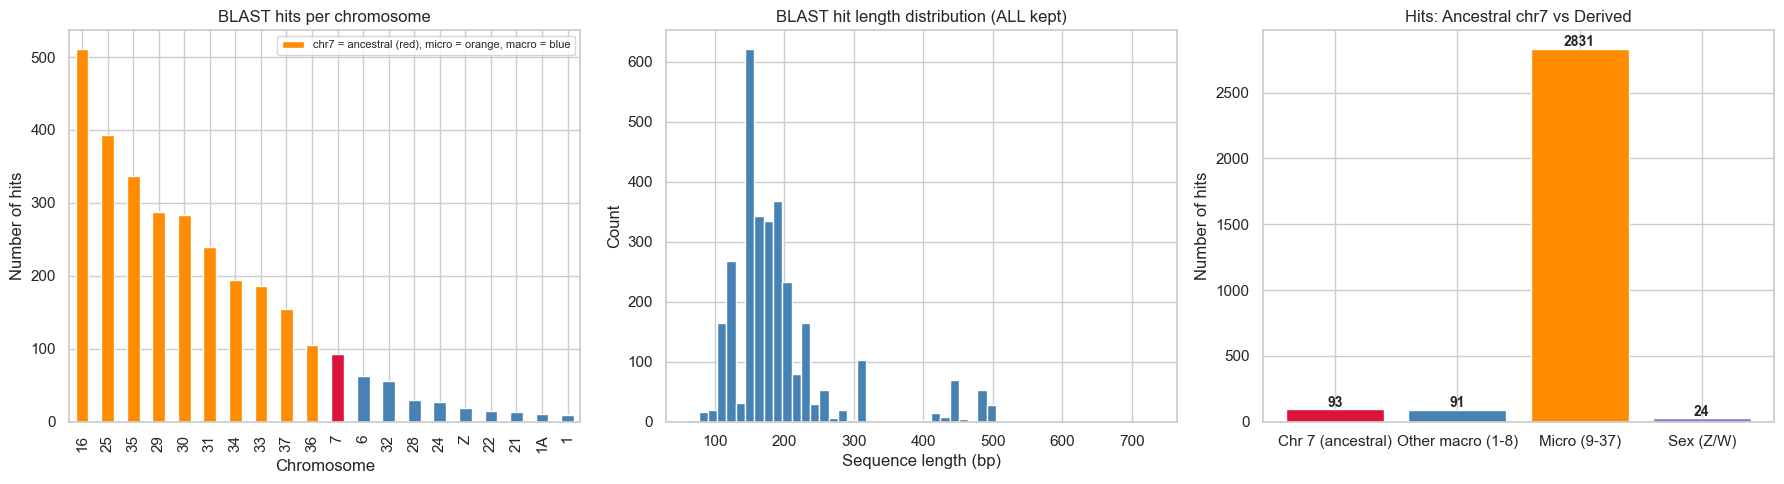

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chromosome distribution
chrom_counts = df['chrom'].value_counts().head(20)
colors = ['crimson' if c == '7' else ('darkorange' if c in ['16','25','29','30','31','33','34','35','36','37'] else 'steelblue')
          for c in chrom_counts.index]
chrom_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('BLAST hits per chromosome')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('Number of hits')
axes[0].legend(['chr7 = ancestral (red), micro = orange, macro = blue'], fontsize=8)

# Sequence length distribution — NO filtering
axes[1].hist(df['seq_len'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('BLAST hit length distribution (ALL kept)')
axes[1].set_xlabel('Sequence length (bp)')
axes[1].set_ylabel('Count')

# Macro vs Micro chromosome breakdown
macro_chroms = ['1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8']
micro_chroms = [c for c in df['chrom'].unique() if c not in macro_chroms and c not in ['Z', 'W', 'unknown']]
cats = {'Chr 7 (ancestral)': len(df[df['chrom'] == '7']),
        'Other macro (1-8)': len(df[(df['chrom'].isin(macro_chroms)) & (df['chrom'] != '7')]),
        'Micro (9-37)': len(df[df['chrom'].isin(micro_chroms)]),
        'Sex (Z/W)': len(df[df['chrom'].isin(['Z', 'W'])])}
axes[2].bar(cats.keys(), cats.values(), color=['crimson', 'steelblue', 'darkorange', 'mediumpurple'])
axes[2].set_title('Hits: Ancestral chr7 vs Derived')
axes[2].set_ylabel('Number of hits')
for i, (k, v) in enumerate(cats.items()):
    axes[2].text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'blast_hit_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 1b. Merge, filter, and classify

**Why merge overlapping hits?** tBLASTn often reports a single genomic copy as
multiple overlapping or adjacent alignment fragments, especially when the
protein query is long and the genomic copy contains frameshifts, stop codons, or
divergent internal regions. A single MROH6 copy spanning ~4,000 bp may produce
5–15 separate BLAST hits. To avoid counting the same copy multiple times, we
merge hits that overlap or fall within 500 bp of each other on the same
chromosome and strand into a single "locus."

**Why 500 bp merge distance?** The MROH6 protein query is ~882 amino acids
(~2,646 bp coding). With introns (which would be absent in retrotransposed
copies but present in the ancestral locus), the full gene span can reach ~4748
bp. A 500 bp max gap allows merging of fragmented alignments from the same copy
while being small enough to avoid merging genuinely separate loci. This is a
standard heuristic in comparative genomics pipelines.

**Why 300 bp minimum length filter?** Very short BLAST fragments are problematic
for evolutionary analysis:
1. **Unreliable divergence estimates** — with fewer than ~200–300 aligned
   positions, sampling variance in the substitution rate becomes large relative
   to the signal (Nei & Kumar, 2000, *Molecular Evolution and Phylogenetics*,
   Oxford University Press)
2. **Inflated NaN rates** — short fragments are more likely to be entirely
   gapped in a multiple alignment, producing NaN when computing pairwise
   divergence (division by zero when total_compared = 0)
3. **Low phylogenetic information** — short sequences provide insufficient data
   for downstream dN/dS analysis (Yang, 2007, *Mol Biol Evol* 24:1586–1591)

The 300 bp threshold retains ~73% of merged loci while removing the noisiest
fragments.

**Why identify the ancestral copy?** All downstream evolutionary analysis is
anchored to the ancestral (parent) MROH6 locus. We know from synteny analysis
that in other vertebrates, MROH6 sits adjacent to LSS on a single chromosome. In
zebra finch, LSS maps to chromosome 7 at ~28.8 Mb, so the largest MROH6 locus in
this region is the ancestral copy. All other copies are "derived" — they were
generated from this source by whatever duplication mechanism operated.

**Chromosome classification rationale:** Avian karyotypes are characterized by a
bimodal chromosome size distribution (International Chicken Genome Sequencing
Consortium, 2004, *Nature* 432:695–716):
- **Macrochromosomes** (chr 1–8, 1A, 4A): Large, gene-poor relative to their
  size, lower recombination rate per Mb
- **Microchromosomes** (chr 9–37+): Small, very gene-dense, high GC content,
  high recombination rate per Mb
- **Sex chromosomes** (Z, W): Distinct evolutionary dynamics — reduced Ne for Z,
  degraded W

We classify loci into these categories because retrotransposed copies may
preferentially insert into gene-dense, accessible regions (microchromosomes),
while DNA duplicates would remain on the parent chromosome (chr 7).

### Processing steps:
1. Merge overlapping hits on the same strand into single-copy loci (500 bp max
   gap)
2. Apply 300 bp minimum length filter
3. Identify the ancestral copy (MROH6 near LSS on chr 7, ~28.8 Mb)
4. Classify every locus by chromosome type

In [4]:
# Length filter: keep loci with total_seq_len >= 300 bp
# Short fragments (<300 bp) produce unreliable divergence estimates
MIN_LENGTH = 300
print(f"Length filter: keeping loci with total_seq_len >= {MIN_LENGTH} bp")

Length filter: keeping loci with total_seq_len >= 300 bp


In [5]:
# Step 2: Merge overlapping hits into loci
loci = merge_overlapping_hits(df, max_gap=500)
print(f"Merged loci: {len(loci)}")
print(f"\nLoci per chromosome:")
print(loci['chrom'].value_counts().head(15))
print(f"\nLocus span (bp) stats:")
print(loci['span'].describe())
print(f"\nTotal sequence length stats:")
print(loci['total_seq_len'].describe())

Merged loci: 812

Loci per chromosome:
chrom
16    198
25    102
35     99
29     64
30     59
31     55
37     43
34     40
33     39
7      20
32     20
36     18
6      14
24     10
Z       8
Name: count, dtype: int64

Locus span (bp) stats:
count     812.000000
mean     1384.311576
std      1105.501113
min        87.000000
25%       246.750000
50%      1115.000000
75%      2192.000000
max      4748.000000
Name: span, dtype: float64

Total sequence length stats:
count     812.000000
mean      720.720443
std       515.239592
min        87.000000
25%       231.000000
50%       666.000000
75%      1182.000000
max      2685.000000
Name: total_seq_len, dtype: float64


In [6]:
# Step 3: Identify ancestral copy
# MROH6 ancestral locus is near LSS on chromosome 7, around position ~28.8 Mb
# Look for loci on chr 7 near this position
chr7 = loci[loci['chrom'] == '7'].sort_values('start')
print("Chromosome 7 loci near 28.8 Mb (putative ancestral MROH6 region):")
ancestral_candidates = chr7[(chr7['start'] > 28_000_000) & (chr7['end'] < 29_500_000)]
print(ancestral_candidates[['locus_id', 'start', 'end', 'strand', 'span', 'n_hits', 'total_seq_len']])

# Flag the largest locus in this region as the ancestral copy
if len(ancestral_candidates) > 0:
    ancestral_idx = ancestral_candidates['total_seq_len'].idxmax()
    ancestral_locus_id = loci.loc[ancestral_idx, 'locus_id']
    print(f"\nAncestral copy: locus_{ancestral_locus_id} (span={loci.loc[ancestral_idx, 'span']} bp)")
    loci['is_ancestral'] = loci['locus_id'] == ancestral_locus_id
else:
    print("WARNING: Could not identify ancestral locus. Manual inspection needed.")
    loci['is_ancestral'] = False

Chromosome 7 loci near 28.8 Mb (putative ancestral MROH6 region):
     locus_id     start       end strand  span  n_hits  total_seq_len
786       786  28454603  28454791      +   189       1            189
787       787  28831543  28836290      +  4748      14           2646

Ancestral copy: locus_787 (span=4748 bp)


In [7]:
# Classify ALL loci first, then apply length filter
# Chromosome classification based on karyotype figures
MACRO_CHROMS = {'1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8'}
SEX_CHROMS = {'Z', 'W'}

def classify_chrom(chrom):
    """Classify chromosome as ancestral, macro, micro, or sex."""
    if chrom == '7':
        return 'chr7_ancestral'
    elif chrom in MACRO_CHROMS:
        return 'macro_derived'
    elif chrom in SEX_CHROMS:
        return 'sex_chrom'
    else:
        return 'micro_derived'

loci['chrom_class'] = loci['chrom'].apply(classify_chrom)

# Apply 300 bp minimum length filter
loci_final = loci[loci['total_seq_len'] >= MIN_LENGTH].copy()

n_removed = len(loci) - len(loci_final)
print(f"Before filter: {len(loci)} merged loci")
print(f"After filter (>= {MIN_LENGTH} bp): {len(loci_final)} loci retained")
print(f"Removed: {n_removed} short fragments (< {MIN_LENGTH} bp)")
print(f"\nChromosome classification (filtered):")
print(loci_final['chrom_class'].value_counts())
print(f"\nSequence length stats (filtered loci):")
print(loci_final['total_seq_len'].describe())
print(f"\n  Full-length (>= 1000 bp): {(loci_final['total_seq_len'] >= 1000).sum()}")
print(f"  Medium (300-999 bp):      {((loci_final['total_seq_len'] >= 300) & (loci_final['total_seq_len'] < 1000)).sum()}")

Before filter: 812 merged loci
After filter (>= 300 bp): 596 loci retained
Removed: 216 short fragments (< 300 bp)

Chromosome classification (filtered):
chrom_class
micro_derived     565
chr7_ancestral     14
macro_derived      10
sex_chrom           7
Name: count, dtype: int64

Sequence length stats (filtered loci):
count     596.000000
mean      933.860738
std       435.991017
min       300.000000
25%       519.000000
50%       801.000000
75%      1332.750000
max      2685.000000
Name: total_seq_len, dtype: float64

  Full-length (>= 1000 bp): 248
  Medium (300-999 bp):      348


In [ ]:
# Write filtered loci to FASTA
n_written = loci_to_fasta(loci_final, DATA_PROC / 'mroh6_copies_filtered.fasta')
print(f"Wrote {n_written} loci to mroh6_copies_filtered.fasta")

# Save loci table with chromosome classification
loci_final.drop(columns=['sequence']).to_csv(DATA_PROC / 'mroh6_loci_table.csv', index=False)
print("Saved loci metadata to mroh6_loci_table.csv")

# Show chr7 vs rest breakdown
print(f"\n--- Chr 7 (parent) vs Derived chromosomes ---")
chr7_loci = loci_final[loci_final['chrom'] == '7']
derived_loci = loci_final[loci_final['chrom'] != '7']
print(f"  Chr 7 loci:     {len(chr7_loci)} ({chr7_loci['total_seq_len'].sum():,} bp total)")
print(f"  Derived loci:   {len(derived_loci)} ({derived_loci['total_seq_len'].sum():,} bp total)")
print(f"  Expansion ratio: {len(derived_loci)/max(len(chr7_loci),1):.1f}x more copies on derived chromosomes")

Wrote 596 loci to mroh6_copies_filtered.fasta
Saved loci metadata to mroh6_loci_table.csv

--- Chr 7 (parent) vs Derived chromosomes ---
  Chr 7 loci:     14 (17,253 bp total)
  Derived loci:   582 (539,328 bp total)
  Expansion ratio: 41.6x more copies on derived chromosomes


## 1c. Align with MAFFT

**Why multiple sequence alignment?** To compute pairwise divergence, Ts/Tv
ratios, and dN/dS, we need homologous positions across all copies to be aligned
column-by-column. Without alignment, we cannot distinguish substitutions from
insertions/deletions, and divergence calculations would be meaningless.

**Why MAFFT?** MAFFT (Katoh & Standley, 2013, *Mol Biol Evol* 30:772–780) uses
Fast Fourier Transform to accelerate the progressive alignment algorithm. We use
`--auto` mode, which automatically selects the optimal strategy based on dataset
size:
- For <200 sequences: L-INS-i (most accurate, iterative refinement)
- For 200–2000 sequences: FFT-NS-2 (fast progressive method)
- `--thread -1` uses all available CPU cores

With 596 sequences, MAFFT will select FFT-NS-2, which balances accuracy and
speed for medium-sized datasets.

**Why trim columns with >50% gaps?** After alignment, many columns will be
dominated by gaps because different copies retain different fragments of the
original gene. Columns where >50% of sequences have gaps carry more noise than
signal:
- Gap-rich columns inflate alignment length without adding phylogenetic
  information
- They increase computational cost of downstream analyses (pairwise matrix,
  PAML)
- Standard practice in comparative genomics is to trim alignment columns above a
  gap threshold of 50–70% (Capella-Gutierrez et al., 2009, *Bioinformatics*
  25:1972–1973, trimAl methodology)

**Calculation:** If an alignment column has $k$ gaps out of $n$ sequences, the
gap fraction is $k/n$. We keep columns where $k/n \leq 0.50$.

In [9]:
# Run MAFFT alignment on filtered loci
input_fasta = DATA_PROC / 'mroh6_copies_filtered.fasta'
output_fasta = DATA_PROC / 'mroh6_aligned.fasta'

result = subprocess.run(
    ['mafft', '--auto', '--thread', '-1', str(input_fasta)],
    capture_output=True, text=True
)

if result.returncode == 0:
    with open(output_fasta, 'w') as f:
        f.write(result.stdout)
    print(f"MAFFT alignment complete: {output_fasta}")
else:
    print(f"MAFFT error:\n{result.stderr}")

MAFFT alignment complete: ../data/processed/mroh6_aligned.fasta


In [10]:
# QC: Alignment statistics
alignment = AlignIO.read(output_fasta, 'fasta')
n_seqs = len(alignment)
aln_len = alignment.get_alignment_length()
print(f"Alignment: {n_seqs} sequences x {aln_len} columns")

# Calculate gap fraction per column
gap_fracs = []
for col_idx in range(aln_len):
    col = alignment[:, col_idx]
    gap_fracs.append(col.count('-') / n_seqs)
gap_fracs = np.array(gap_fracs)

print(f"Columns with >50% gaps: {(gap_fracs > 0.5).sum()} / {aln_len}")
print(f"Columns with 0% gaps: {(gap_fracs == 0).sum()} / {aln_len}")

Alignment: 596 sequences x 9776 columns
Columns with >50% gaps: 9275 / 9776
Columns with 0% gaps: 0 / 9776


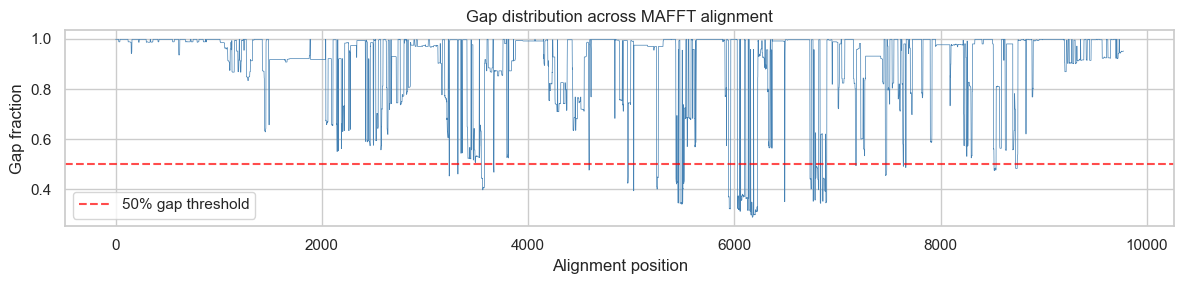

In [11]:
# Visualize gap distribution
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gap_fracs, color='steelblue', linewidth=0.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% gap threshold')
ax.set_xlabel('Alignment position')
ax.set_ylabel('Gap fraction')
ax.set_title('Gap distribution across MAFFT alignment')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'alignment_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Remove columns with >50% gaps and save trimmed alignment
keep_cols = np.where(gap_fracs <= 0.5)[0]
trimmed_records = []
for record in alignment:
    trimmed_seq = ''.join(str(record.seq)[i] for i in keep_cols)
    trimmed_records.append(SeqRecord(Seq(trimmed_seq), id=record.id, description=''))

trimmed_path = DATA_PROC / 'mroh6_aligned_trimmed.fasta'
SeqIO.write(trimmed_records, trimmed_path, 'fasta')
print(f"Trimmed alignment: {len(trimmed_records)} sequences x {len(keep_cols)} columns")
print(f"Saved to {trimmed_path}")

Trimmed alignment: 596 sequences x 501 columns
Saved to ../data/processed/mroh6_aligned_trimmed.fasta


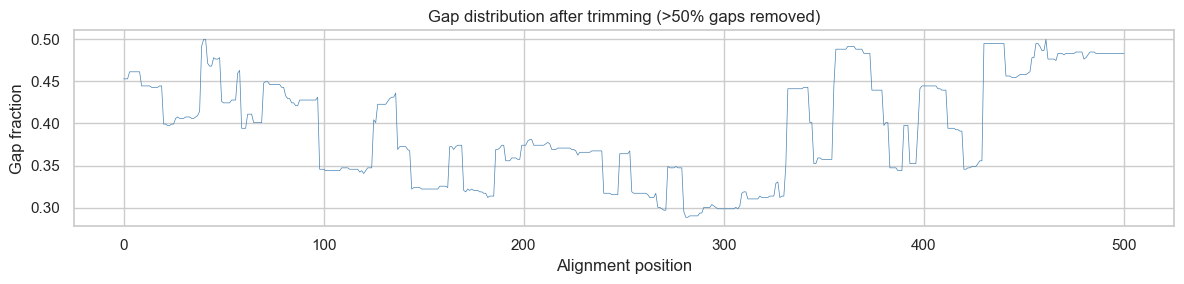

In [13]:
# Visualize gap distribution after trimming
trimmed_alignment = AlignIO.read(trimmed_path, 'fasta')
n_seqs_trimmed = len(trimmed_alignment)
aln_len_trimmed = trimmed_alignment.get_alignment_length()
gap_fracs_trimmed = []
for col_idx in range(aln_len_trimmed):
    col = trimmed_alignment[:, col_idx]
    gap_fracs_trimmed.append(col.count('-') / n_seqs_trimmed)
gap_fracs_trimmed = np.array(gap_fracs_trimmed)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gap_fracs_trimmed, color='steelblue', linewidth=0.5)
ax.set_xlabel('Alignment position')
ax.set_ylabel('Gap fraction')
ax.set_title('Gap distribution after trimming (>50% gaps removed)')
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'alignment_gap_distribution_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Summary
print("="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"Raw BLAST hits:          {len(df)}")
print(f"Merged loci:             {len(loci)}")
print(f"Length filter:           >= {MIN_LENGTH} bp")
print(f"Filtered loci:           {len(loci_final)}  (removed {len(loci) - len(loci_final)} short fragments)")
print(f"  Chr 7 (ancestral):     {len(loci_final[loci_final['chrom']=='7'])}")
print(f"  Macro-derived:         {len(loci_final[loci_final['chrom_class']=='macro_derived'])}")
print(f"  Micro-derived:         {len(loci_final[loci_final['chrom_class']=='micro_derived'])}")
print(f"  Sex chromosomes:       {len(loci_final[loci_final['chrom_class']=='sex_chrom'])}")
if 'is_ancestral' in loci_final.columns:
    anc = loci_final[loci_final['is_ancestral']]
    if len(anc) > 0:
        print(f"Ancestral copy:          locus_{anc.iloc[0]['locus_id']} (chr7, {anc.iloc[0]['span']}bp span)")
print(f"\n=> Proceed to Step 02 with {len(loci_final)} filtered loci")

DATA PREPARATION SUMMARY
Raw BLAST hits:          3039
Merged loci:             812
Length filter:           >= 300 bp
Filtered loci:           596  (removed 216 short fragments)
  Chr 7 (ancestral):     14
  Macro-derived:         10
  Micro-derived:         565
  Sex chromosomes:       7
Ancestral copy:          locus_787 (chr7, 4748bp span)

=> Proceed to Step 02 with 596 filtered loci
